In [1]:
from pathlib import Path
import torch
import numpy as np

from rtnls_models import KeypointsEnsemble
from rtnls_models import ArteryVeinSegmentor, DiscDetector
from rtnls_enface import FundusLoader
from rtnls_enface.utils.plotting import plot_gridfns

## Segmentation of preprocessed images

Here we segment images preprocessed using 0_preprocess.ipynb

In [2]:
ds_path = Path("../../samples/fundus/ergo/good")

# input folder. point to a folder with png and/or dicom images
npy_path = ds_path / "preprocessed_npy"

# these are the output folders:
av_path = ds_path / "av"
overlays_path = ds_path / "overlays"
discs_path = ds_path / "discs"

device = torch.device("cuda:0")

### Artery-vein segmentation

In [3]:
# set the model to use here. This one is working okay.
av_model = ArteryVeinSegmentor(device=device, model_name='nonmasked_mild-augment_16')
# run the model, pass the path for the outputs
av_model.predict(npy_path, dest_path=av_path, num_workers=2, preprocess=False)

Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]
Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]


100%|██████████| 16/16 [00:27<00:00,  1.71s/it]


### Disc segmentation

In [4]:
disc_model = DiscDetector(device=device)
disc_model.predict(npy_path, dest_path=discs_path, preprocess=False)

/home/jose/miniconda3/lib/python3.10/site-packages/pytorch_lightning/utilities/migration/migration.py:195: PossibleUserWarning: You have multiple `ModelCheckpoint` callback states in this checkpoint, but we found state keys that would end up colliding with each other after an upgrade, which means we can't differentiate which of your checkpoint callbacks needs which states. At least one of your `ModelCheckpoint` callbacks will not be able to reload the state.
  rank_zero_warn(
Lightning automatically upgraded your loaded checkpoint from v1.3.8 to v1.9.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint --file ../disc/models/latest.ckpt`


Filters: [32, 64, 96, 128, 192, 256, 384, 512],
Kernels: [[3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3], [3, 3]]
Strides: [[1, 1], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2], [2, 2]]


16it [00:00, 45.84it/s]


### Fovea detection

In [7]:
fovea_model = KeypointsEnsemble(device=device, model_name="r101_b16_001")
df = fovea_model.predict(npy_path, preprocess=False)

1it [00:01,  1.03s/it]


In [8]:
df.head(10)

,x0,y0,x1,y1,x2,y2,x3,y3,x4,y4
210281,157.532013,552.134949,147.793427,547.953857,163.481979,543.508301,160.682785,556.205444,187.056778,554.832764
245938,497.969513,522.719299,498.956177,510.004883,484.042572,514.330566,493.026001,538.828186,485.839111,536.277100
252853,507.086243,513.696411,498.778290,504.101562,530.872498,511.888794,501.196716,518.149841,509.433807,515.623718
279724,510.269104,534.101196,518.838257,516.084106,532.973938,530.292480,511.983185,541.074890,532.811462,539.388184
318392,144.283066,560.594727,166.127869,562.834534,156.835831,560.604553,140.592834,561.627441,167.375076,567.279297
344501,436.797699,523.498962,414.578186,524.040283,431.806335,527.155762,411.119934,528.721191,428.851471,527.797546
353780,114.673782,578.419128,113.556801,567.152161,101.755585,586.275940,102.980652,577.182190,132.785187,587.350586
360268,117.765572,636.835449,120.117279,632.488220,108.015877,633.933655,125.718109,629.319885,141.808258,630.529846
375802,505.341644,533.668213,507.175842,528.165405,523.705444,537.045837,502.637085,556.223022,504.277344,545.608826
560772,862.238525,579.428406,843.974792,568.434692,851.128601,573.442383,851.995239,587.538696,864.826965,581.536072


In [9]:
# the fovea model returns a dataframe with the fovea locations predictions by 5 models (x1,y1),(x2,y2),(x3,y3),(x4,y4),(x5,y5)
# here we average the predictions of the 5 models before storing the dataframe
df["mean_x"] = np.mean([df[f"x{i}"] for i in range(0, 5)], axis=0)
df["mean_y"] = np.mean([df[f"y{i}"] for i in range(0, 5)], axis=0)
df.to_csv(ds_path / "fovea.csv")

### Plotting the retinas

This will only work if you ran all the models and stored the outputs using the same folder/file names as above

In [10]:
loader = FundusLoader.from_folder(ds_path, fundus_subfolder='preprocessed_rgb')

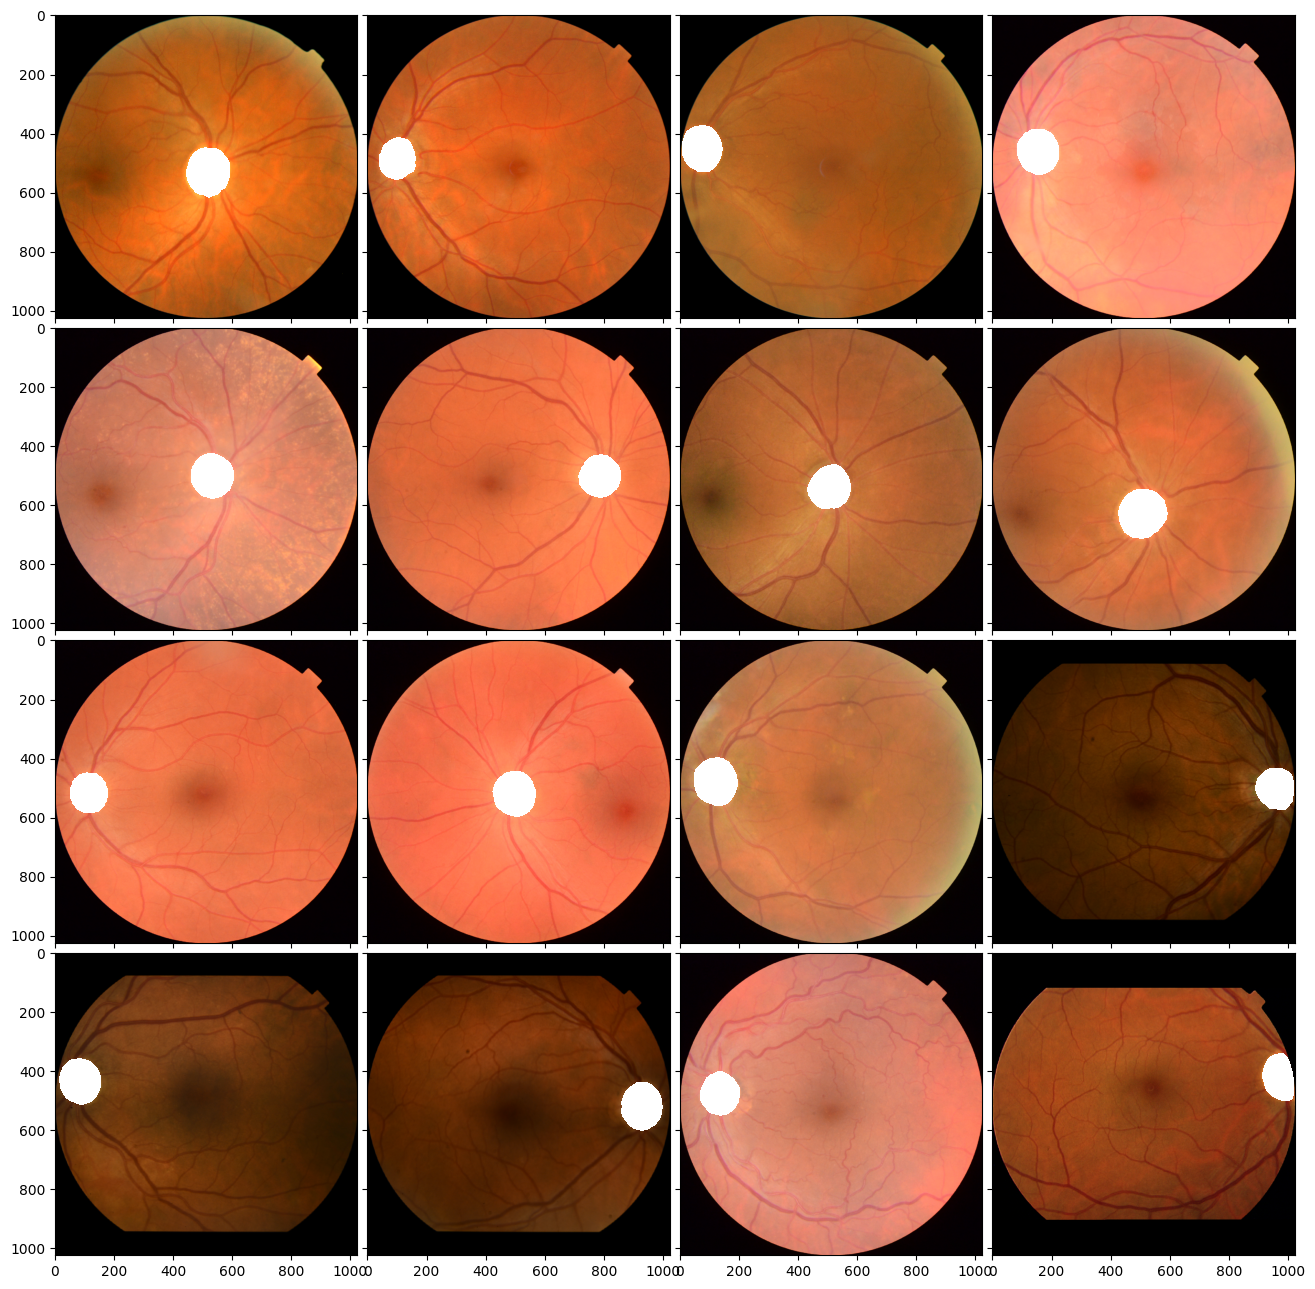

In [11]:
plot_gridfns([ret.plot for ret in loader])